In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]).reshape(-1, 1)

y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8, 1)
y shape: (8,)


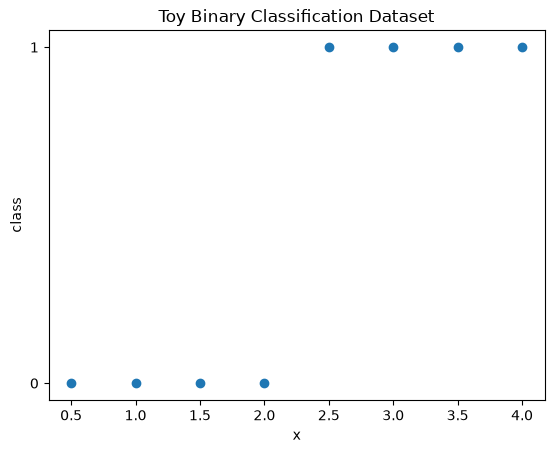

In [2]:
plt.scatter(X[:, 0], y)
plt.xlabel("x")
plt.ylabel("class")
plt.yticks([0, 1])
plt.title("Toy Binary Classification Dataset")
plt.show()

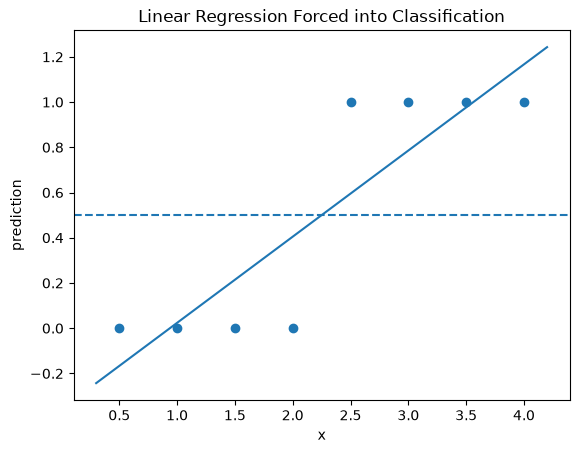

In [4]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X,y)

x_line = np.linspace(0.3, 4.2, 200).reshape(-1, 1)
y_line = lin_model.predict(x_line)

plt.scatter(X[:, 0], y)
plt.plot(x_line[:, 0], y_line)

plt.axhline(0.5, linestyle="--")

plt.xlabel("x")
plt.ylabel("prediction")
plt.title("Linear Regression Forced into Classification")
plt.show()

In [5]:
w = lin_model.coef_[0]
b = lin_model.intercept_

boundary = (0.5 - b) / w

print("w:", w)
print("b:", b)
print("decision boundary:", boundary)

w: 0.38095238095238104
b: -0.3571428571428573
decision boundary: 2.25


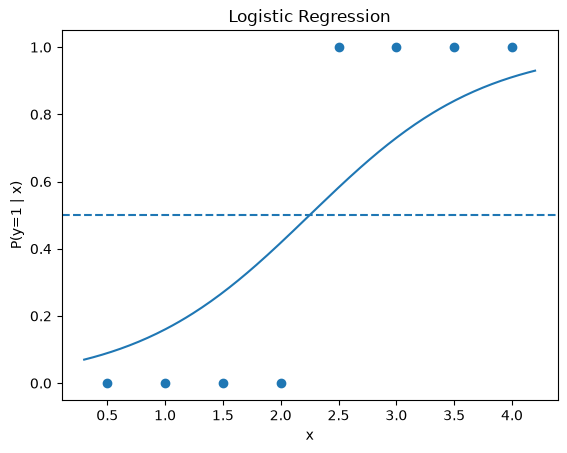

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X, y)

x_line = np.linspace(0.3, 4.2, 200).reshape(-1, 1)

probs = log_model.predict_proba(x_line)[:, 1]

plt.scatter(X[:, 0], y)
plt.plot(x_line[:, 0], probs)

plt.axhline(0.5, linestyle="--")

plt.xlabel("x")
plt.ylabel("P(y=1 | x)")
plt.title("Logistic Regression")
plt.show()

In [7]:
w_log = log_model.coef_[0, 0]
b_log = log_model.intercept_[0]

boundary_log = -b_log / w_log

print("w:", w_log)
print("b:", b_log)
print("decision boundary:", boundary_log)

w: 1.3265520323700475
b: -2.9847798687963585
decision boundary: 2.250028491881833


In [8]:
X_out = np.vstack([X, [[10.0]]])
y_out = np.append(y, 1)

lin_out = LinearRegression()
lin_out.fit(X_out, y_out)

w_out = lin_out.coef_[0]
b_out = lin_out.intercept_

boundary_out = (0.5 - b_out) / w_out

print("Old linear boundary:", boundary)
print("New linear boundary:", boundary_out)

Old linear boundary: 2.25
New linear boundary: 2.634328358208955


In [9]:
log_out = LogisticRegression()
log_out.fit(X_out, y_out)

w_log_out = log_out.coef_[0, 0]
b_log_out = log_out.intercept_[0]

boundary_log_out = -b_log_out / w_log_out

print("Old logistic boundary:", boundary_log)
print("New logistic boundary:", boundary_log_out)

Old logistic boundary: 2.250028491881833
New logistic boundary: 2.249948343027243


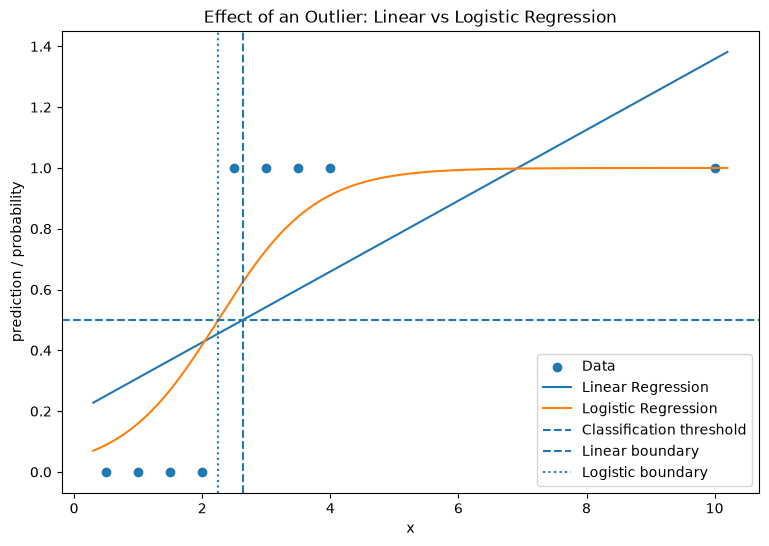

In [10]:
x_line = np.linspace(0.3, 10.2, 400).reshape(-1, 1)

lin_pred_out = lin_out.predict(x_line)
log_prob_out = log_out.predict_proba(x_line)[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(X_out[:, 0], y_out, label="Data")
plt.plot(x_line[:, 0],lin_pred_out,label="Linear Regression")
plt.plot(x_line[:, 0],log_prob_out,label="Logistic Regression")
plt.axhline(0.5,linestyle="--",label="Classification threshold")
plt.axvline(boundary_out,linestyle="--",label="Linear boundary")
plt.axvline(boundary_log_out,linestyle=":",label="Logistic boundary")
plt.xlabel("x")
plt.ylabel("prediction / probability")
plt.title("Effect of an Outlier: Linear vs Logistic Regression")
plt.legend()
plt.show()

# Conclusion
Linear regression can be forced into binary classification by applying a threshold, but it is not designed for this task. Its predictions are unbounded, and an extreme input can significantly shift the fitted line and therefore the decision boundary.

Logistic regression instead models

$$
P(y=1 \mid x) = \sigma(w^T x + b)
$$

so its output stays between 0 and 1. With a threshold of 0.5, the decision boundary occurs where

$$
w^T x + b = 0
$$

In the toy experiment, adding a distant class-1 point moved the linear-regression boundary from 2.25 to about 2.63, while the logistic-regression boundary remained almost unchanged at 2.25.

This illustrates why logistic regression is a more appropriate model for binary classification.